
# Location-Specific Landslide Risk Scoring Index (LS-LRSI)
## Yatinuwara Divisional Secretariat Division, Kandy District, Sri Lanka

**Required solution statement**

> **I propose a Location-Specific Landslide Risk Scoring Index (LS-LRSI) for Yatinuwara Divisional Secretariat Division, Kandy District, Sri Lanka.**

This notebook implements a reproducible practical workflow at a **30 m grid**:

**Yatinuwara boundary → Copernicus DEM → slope → CHIRPS rainfall → ESA WorldCover → SoilGrids → OSM roads → OSM streams → NASA landslide inventory → WorldPop exposure → 0–100 LS-LRSI.**

### Important interpretation
The final baseline map is a **screening/index product**, not an NBRO warning product and not a substitute for site-specific geotechnical investigation.

The source layers have different native resolutions. In particular, **CHIRPS (~0.05°)**, **SoilGrids (250 m)** and **WorldPop (~100 m)** are aligned to the 30 m computational grid, but this does **not** create new 30 m information.



## Exact data sources used

1. **Boundary – Sri Lanka NSDI Survey_10k**  
   `https://gisapps.nsdi.gov.lk/server/rest/services/SLNSDI/Survey_10k/MapServer/3`  
   Field: `ds_division_name`; source CRS: EPSG:4326.

2. **DEM – Copernicus DEM GLO-30, N07E080 tile**  
   Public AWS dataset: `s3://copernicus-dem-30m/`  
   Object attempted by this notebook:  
   `Copernicus_DSM_COG_10_N07_00_E080_00_DEM/Copernicus_DSM_COG_10_N07_00_E080_00_DEM.tif`

3. **Rainfall – CHIRPS v2 annual 1981–2024 climatology**  
   `https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_annual/tifs/chirps-v2.0.1981-2024.44yrs.tif`

4. **Land cover – ESA WorldCover 2021 v200, tile N06E078**  
   `https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N06E078_Map.tif`

5. **Soil – SoilGrids 2.0 clay 15–30 cm mean**  
   `https://files.isric.org/soilgrids/latest/data/clay/clay_15-30cm_mean.vrt`

6. **Roads and streams – OpenStreetMap**  
   Reproducible national archive: `https://download.geofabrik.de/asia/sri-lanka-latest-free.gpkg.zip`  
   The notebook uses OSMnx/Overpass to retrieve only the Yatinuwara subset.

7. **Historical landslides – NASA Global Landslide Catalog / COOLR**  
   `https://services9.arcgis.com/wb84GxCwiPzK3Eow/ArcGIS/rest/services/nasa_global_landslide_catalog_point/FeatureServer/0/query`

8. **Population – WorldPop 2024 R2024A, 100 m unconstrained**  
   `https://data.worldpop.org/GIS/Population/Global_2015_2030/R2024A/2024/LKA/v1/100m/unconstrained/lka_pop_2024_UC_100m_R2024A_v1.tif`



## 0. Environment

Run this notebook in a normal internet-enabled Python environment or Google Colab.  
If packages are missing, uncomment the installation cell.


In [1]:
# Uncomment once if required (e.g., Google Colab)
# %pip install -q geopandas shapely pyproj rasterio rioxarray xarray requests scipy matplotlib osmnx tqdm scikit-learn


In [ ]:

from pathlib import Path
from math import floor, ceil
import json, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt
from scipy.spatial import cKDTree
from shapely.geometry import box
from pyproj import CRS, Geod, Transformer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import osmnx as ox
except Exception:
    ox = None

# ---------------- CONFIG ----------------
STUDY_NAME = "Yatinuwara"
DISTRICT = "Kandy"
TARGET_CRS = "EPSG:32644"   # WGS 84 / UTM zone 44N; metric CRS covering Yatinuwara
GRID_RES_M = 30.0

ROOT = Path.cwd()
DATA = ROOT / "data"
RAW = DATA / "raw"
PROC = DATA / "processed"
OUT = ROOT / "outputs"
FIG = OUT / "figures"
TABLE = OUT / "tables"

for d in [RAW, PROC, OUT, FIG, TABLE]:
    d.mkdir(parents=True, exist_ok=True)

print("Working directory:", ROOT)
print("Target CRS:", TARGET_CRS)
print("Grid resolution:", GRID_RES_M, "m")


/Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical
Target CRS: EPSG:32644
Grid resolution: 30.0 m



## 1. Utility functions

These functions:
- Download files with retry/fallback,
- Build the common 30 m reference grid,
- Reproject/resample raster layers,
- Write GeoTIFFs,
- Normalize indicators transparently to 0–1,
- Save one map per figure.


In [3]:

def download_with_fallback(urls, out_path, timeout=180, chunk=1024*1024):
    """Download from the first working URL."""
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 0:
        print("Exists:", out_path)
        return out_path
    last_error = None
    for url in urls:
        try:
            print("Downloading:", url)
            with requests.get(url, stream=True, timeout=timeout, allow_redirects=True) as r:
                r.raise_for_status()
                total = int(r.headers.get("content-length", 0))
                with open(out_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
                    for b in r.iter_content(chunk_size=chunk):
                        if b:
                            f.write(b)
                            bar.update(len(b))
            if out_path.stat().st_size == 0:
                raise IOError("Downloaded file is empty")
            return out_path
        except Exception as e:
            last_error = e
            print("  failed:", repr(e))
            if out_path.exists():
                out_path.unlink()
    raise RuntimeError(f"All URLs failed for {out_path}. Last error: {last_error}")

def save_gdf(gdf, path, layer=None):
    path = Path(path)
    if path.exists():
        path.unlink()
    if path.suffix.lower() == ".gpkg":
        gdf.to_file(path, layer=layer or path.stem, driver="GPKG")
    else:
        gdf.to_file(path)
    return path

def snapped_grid(bounds, res=30):
    minx, miny, maxx, maxy = bounds
    minx = floor(minx/res)*res
    miny = floor(miny/res)*res
    maxx = ceil(maxx/res)*res
    maxy = ceil(maxy/res)*res
    width = int(round((maxx-minx)/res))
    height = int(round((maxy-miny)/res))
    transform = from_origin(minx, maxy, res, res)
    return transform, width, height

def template_profile(transform, width, height, crs=TARGET_CRS, dtype="float32", nodata=-9999):
    return dict(
        driver="GTiff", height=height, width=width, count=1,
        dtype=dtype, crs=crs, transform=transform,
        nodata=nodata, compress="deflate", tiled=True
    )

def warp_to_template(src_path_or_url, transform, width, height, dst_crs=TARGET_CRS,
                     resampling=Resampling.bilinear, dst_nodata=np.nan):
    """Read band 1 and warp to the common reference grid."""
    src_str = str(src_path_or_url)
    # /vsicurl/ is helpful for remote VRT/COG access.
    if src_str.startswith("http") and src_str.endswith(".vrt"):
        src_str = "/vsicurl/" + src_str
    with rasterio.Env(GDAL_HTTP_MULTIRANGE="YES", GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES"):
        with rasterio.open(src_str) as src:
            dst = np.full((height, width), np.nan, dtype="float32")
            reproject(
                source=rasterio.band(src, 1),
                destination=dst,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=transform,
                dst_crs=dst_crs,
                dst_nodata=np.nan,
                resampling=resampling
            )
    return dst

def boundary_mask(boundary_utm, transform, shape):
    m = rasterize(
        [(geom, 1) for geom in boundary_utm.geometry],
        out_shape=shape, transform=transform,
        fill=0, all_touched=False, dtype="uint8"
    )
    return m.astype(bool)

def write_float_tif(path, arr, transform, crs=TARGET_CRS):
    path = Path(path)
    prof = template_profile(transform, arr.shape[1], arr.shape[0], crs=crs)
    data = np.where(np.isfinite(arr), arr, -9999).astype("float32")
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(data, 1)
    return path

def write_byte_tif(path, arr, transform, crs=TARGET_CRS, nodata=0):
    path = Path(path)
    prof = template_profile(transform, arr.shape[1], arr.shape[0], crs=crs,
                            dtype="uint8", nodata=nodata)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr.astype("uint8"), 1)
    return path

def robust_scale(a, mask=None, low=5, high=95, invert=False, neutral_if_constant=0.5):
    x = a.astype("float32").copy()
    valid = np.isfinite(x)
    if mask is not None:
        valid &= mask
    if valid.sum() == 0:
        return np.full_like(x, np.nan), {"p_low": None, "p_high": None}
    lo, hi = np.nanpercentile(x[valid], [low, high])
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi-lo) < 1e-12:
        z = np.full_like(x, neutral_if_constant, dtype="float32")
    else:
        z = np.clip((x-lo)/(hi-lo), 0, 1).astype("float32")
    if invert:
        z = 1-z
    z[~valid] = np.nan
    return z, {"p_low": float(lo), "p_high": float(hi), "invert": bool(invert)}

def fixed_scale(a, lo, hi, mask=None, invert=False):
    z = np.clip((a-lo)/(hi-lo), 0, 1).astype("float32")
    if invert:
        z = 1-z
    if mask is not None:
        z[~mask] = np.nan
    z[~np.isfinite(a)] = np.nan
    return z

def plot_raster(arr, title, unit, out_file, mask=None):
    x = arr.copy()
    if mask is not None:
        x = np.where(mask, x, np.nan)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(x)
    ax.set_title(title)
    ax.set_axis_off()
    cb = fig.colorbar(im, ax=ax, shrink=0.75)
    cb.set_label(unit)
    fig.tight_layout()
    fig.savefig(out_file, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def raster_stats(name, arr, mask):
    v = arr[np.isfinite(arr) & mask]
    if len(v) == 0:
        return dict(feature=name, n=0, min=np.nan, p05=np.nan, median=np.nan,
                    mean=np.nan, p95=np.nan, max=np.nan, std=np.nan)
    return dict(
        feature=name, n=int(v.size), min=float(np.min(v)),
        p05=float(np.percentile(v, 5)), median=float(np.median(v)),
        mean=float(np.mean(v)), p95=float(np.percentile(v,95)),
        max=float(np.max(v)), std=float(np.std(v))
    )



## 2. Download the Yatinuwara DSD boundary

**Primary source:** Sri Lanka NSDI `Divisional_Secretariat_10K` Feature Layer.

The code first queries both `ds_division_name='Yatinuwara'` and `district_name='Kandy'`.  
If the server schema/service behaves differently, it retries with the DSD name alone.  
Only if NSDI fails does it use **GADM 4.1** as a documented fallback.

A published approximate Yatinuwara extent is used only as a QA check, not as the boundary itself.


NSDI query returned 0 features for ds_division_name='Yatinuwara' AND district_name='Kandy'
NSDI query returned 0 features for ds_division_name='Yatinuwara'
Using documented GADM fallback.
GADM 4.1 fallback
EPSG: EPSG:4326
Bounds: (np.float64(80.4701), np.float64(7.2452), np.float64(80.6067), np.float64(7.3183))
Area (km²): 71.145


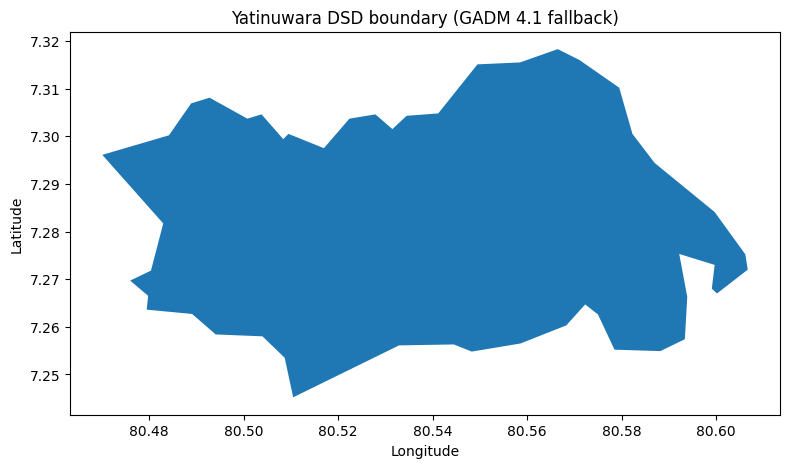

In [4]:

NSDI_QUERY = "https://gisapps.nsdi.gov.lk/server/rest/services/SLNSDI/Survey_10k/MapServer/3/query"
GADM_FALLBACK = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_2.json"

def fetch_boundary():
    attempts = [
        "ds_division_name='Yatinuwara' AND district_name='Kandy'",
        "ds_division_name='Yatinuwara'"
    ]
    for where in attempts:
        try:
            params = {
                "where": where,
                "outFields": "*",
                "returnGeometry": "true",
                "outSR": "4326",
                "f": "geojson"
            }
            r = requests.get(NSDI_QUERY, params=params, timeout=90)
            r.raise_for_status()
            js = r.json()
            if len(js.get("features", [])) == 1:
                g = gpd.GeoDataFrame.from_features(js["features"], crs="EPSG:4326")
                print("Boundary source: Sri Lanka NSDI")
                print("Query:", r.url)
                return g, "Sri Lanka NSDI Survey_10k"
            print("NSDI query returned", len(js.get("features", [])), "features for", where)
        except Exception as e:
            print("NSDI attempt failed:", repr(e))

    print("Using documented GADM fallback.")
    g = gpd.read_file(GADM_FALLBACK)
    # GADM level-2 field names.
    mask = g["NAME_2"].astype(str).str.casefold().eq("yatinuwara")
    if "NAME_1" in g:
        mask &= g["NAME_1"].astype(str).str.casefold().eq("kandy")
    out = g.loc[mask].copy()
    if len(out) != 1:
        raise RuntimeError(f"Fallback boundary selection returned {len(out)} features.")
    return out.to_crs("EPSG:4326"), "GADM 4.1 fallback"

boundary, boundary_source = fetch_boundary()
boundary = boundary[["geometry"] + [c for c in boundary.columns if c != "geometry"]].copy()
boundary = boundary[boundary.geometry.notna()].copy()
boundary["geometry"] = boundary.geometry.buffer(0)

print(boundary_source)
print("EPSG:", boundary.crs)
print("Bounds:", tuple(round(x, 6) for x in boundary.total_bounds))

# Approximate independent QA extent, not used as the analytical boundary.
qa_bbox = (80.472815, 7.246205, 80.601866, 7.318729)
minx, miny, maxx, maxy = boundary.total_bounds
tol = 0.06
assert minx > qa_bbox[0]-tol and maxx < qa_bbox[2]+tol, "Boundary longitude outside expected Yatinuwara range."
assert miny > qa_bbox[1]-tol and maxy < qa_bbox[3]+tol, "Boundary latitude outside expected Yatinuwara range."

boundary_path = save_gdf(boundary, PROC/"yatinuwara_boundary.gpkg", layer="yatinuwara")
boundary_utm = boundary.to_crs(TARGET_CRS)
print("Area (km²):", round(boundary_utm.area.sum()/1e6, 3))

fig, ax = plt.subplots(figsize=(8,6))
boundary.plot(ax=ax)
ax.set_title(f"Yatinuwara DSD boundary ({boundary_source})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.tight_layout()
fig.savefig(FIG/"01_yatinuwara_boundary.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)



## 3. Create the common 30 m grid

All analytical layers are aligned to **EPSG:32644 (UTM 44N)** for metric slope/distance calculations.

The grid is snapped to 30 m coordinates and masked to the Yatinuwara polygon.


In [5]:

transform, width, height = snapped_grid(boundary_utm.total_bounds, GRID_RES_M)
shape = (height, width)
study_mask = boundary_mask(boundary_utm, transform, shape)

print("Grid:", width, "x", height, "=", width*height, "cells")
print("Valid Yatinuwara cells:", int(study_mask.sum()))
print("Approximate valid grid area (km²):", round(study_mask.sum()*GRID_RES_M*GRID_RES_M/1e6, 3))


Grid: 504 x 270 = 136080 cells
Valid Yatinuwara cells: 79042
Approximate valid grid area (km²): 71.138



## 4. Copernicus DEM and derived slope

The primary DEM is **Copernicus DEM GLO-30**.  
Yatinuwara lies inside the **N07E080** 1° tile.

Slope is calculated only after reprojecting the DEM to the metric 30 m UTM grid:

\[
\mathrm{slope}=\tan^{-1}\left(\sqrt{(\partial z/\partial x)^2+(\partial z/\partial y)^2}\right)
\]

and reported in degrees.


Downloading: https://copernicus-dem-30m.s3.eu-central-1.amazonaws.com/Copernicus_DSM_COG_10_N07_00_E080_00_DEM/Copernicus_DSM_COG_10_N07_00_E080_00_DEM.tif


100%|██████████| 48.2M/48.2M [00:14<00:00, 3.37MB/s]


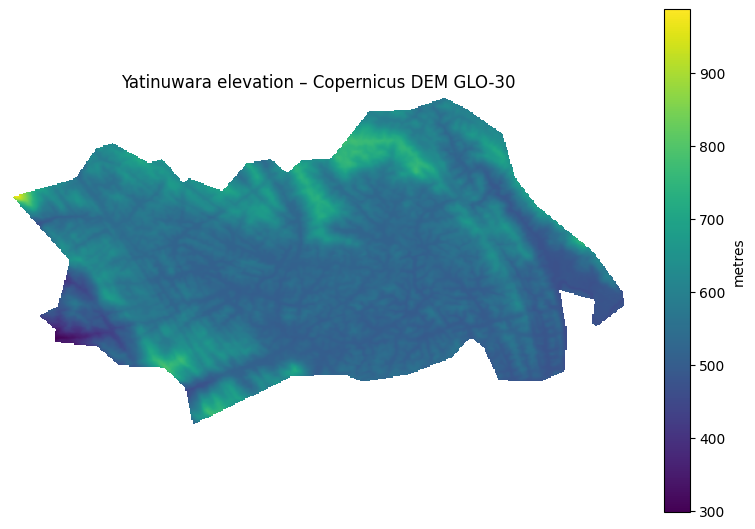

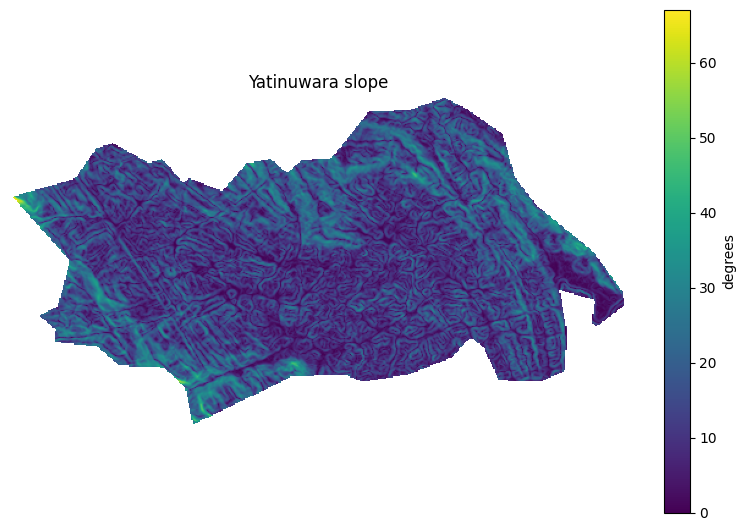

In [6]:

DEM_URLS = [
    "https://copernicus-dem-30m.s3.eu-central-1.amazonaws.com/"
    "Copernicus_DSM_COG_10_N07_00_E080_00_DEM/"
    "Copernicus_DSM_COG_10_N07_00_E080_00_DEM.tif",
    "https://pete.stanford.edu/sesfs/srtm30/coptif/"
    "Copernicus_DSM_COG_10_N07_00_E080_00_DEM.tif"
]
dem_raw = download_with_fallback(DEM_URLS, RAW/"copernicus_dem_N07E080.tif")

dem_full = warp_to_template(dem_raw, transform, width, height, resampling=Resampling.bilinear)
# Keep a complete small bounding rectangle for numerical derivatives, then mask outputs.
dy, dx = np.gradient(dem_full.astype("float64"), GRID_RES_M, GRID_RES_M)
slope = np.degrees(np.arctan(np.hypot(dx, dy))).astype("float32")

dem = np.where(study_mask, dem_full, np.nan).astype("float32")
slope = np.where(study_mask, slope, np.nan).astype("float32")

write_float_tif(PROC/"elevation_30m.tif", dem, transform)
write_float_tif(PROC/"slope_degrees_30m.tif", slope, transform)

plot_raster(dem, "Yatinuwara elevation – Copernicus DEM GLO-30", "metres", FIG/"02_elevation.png", study_mask)
plot_raster(slope, "Yatinuwara slope", "degrees", FIG/"03_slope.png", study_mask)



## 5. CHIRPS rainfall

For a reproducible **baseline** map, this notebook uses the CHIRPS v2 **1981–2024 annual climatology**.

Native rainfall support is 0.05° (~5 km). It is geometrically aligned to the 30 m grid, but the resulting 30 m cells must not be interpreted as independent 30 m rainfall measurements.

The baseline trigger score uses fixed normalization anchors of **1500–3500 mm/year**. These are **index scaling anchors**, not official NBRO warning thresholds.

For an operational future update, replace this climatology with CHIRPS daily 1-, 3- and 7-day accumulations or local rain-gauge data.


Downloading: https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_annual/tifs/chirps-v2.0.1981-2024.44yrs.tif


100%|██████████| 57.6M/57.6M [00:31<00:00, 1.83MB/s]


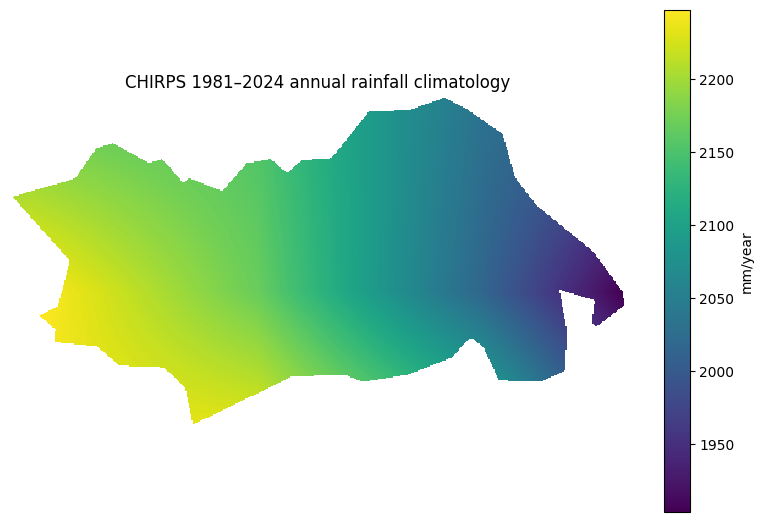

In [7]:

CHIRPS_URL = (
    "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_annual/tifs/"
    "chirps-v2.0.1981-2024.44yrs.tif"
)
rain_raw = download_with_fallback([CHIRPS_URL], RAW/"chirps_v2_1981_2024_44yrs.tif")
rain = warp_to_template(rain_raw, transform, width, height, resampling=Resampling.bilinear)
rain = np.where(study_mask, rain, np.nan).astype("float32")
write_float_tif(PROC/"rainfall_climatology_mm_year_30m_aligned.tif", rain, transform)

# Fixed physical scaling anchors avoid exaggerated within-DS variation from a handful of coarse CHIRPS cells.
rain_score = fixed_scale(rain, 1500.0, 3500.0, study_mask)
write_float_tif(PROC/"rainfall_trigger_score_0_1.tif", rain_score, transform)

plot_raster(rain, "CHIRPS 1981–2024 annual rainfall climatology", "mm/year", FIG/"04_rainfall.png", study_mask)



## 6. ESA WorldCover 2021 v200

Yatinuwara is inside the **N06E078** 3°×3° WorldCover tile.

Categorical land cover is resampled with **nearest neighbour**. The following transparent baseline evidence scores are used:

| WorldCover class | Code | Baseline score |
|---|---:|---:|
| Tree cover | 10 | 0.25 |
| Shrubland | 20 | 0.45 |
| Grassland | 30 | 0.55 |
| Cropland | 40 | 0.65 |
| Built-up | 50 | 0.70 |
| Bare / sparse vegetation | 60 | 0.85 |
| Snow / ice | 70 | 0.00 |
| Permanent water | 80 | 0.00 |
| Herbaceous wetland | 90 | 0.40 |
| Mangroves | 95 | 0.10 |
| Moss / lichen | 100 | 0.20 |

These are **literature-informed starting scores**, not universal causal constants; sensitivity testing should vary them.


Downloading: https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N06E078_Map.tif


100%|██████████| 34.4M/34.4M [00:17<00:00, 1.94MB/s]
/var/folders/sw/2g04krvs2mvfntsj2sfylnz40000gn/T/ipykernel_14943/2000580018.py:16: RuntimeWarning: invalid value encountered in cast
  lc_score[np.isfinite(landcover) & (landcover.astype("int32") == code)] = score


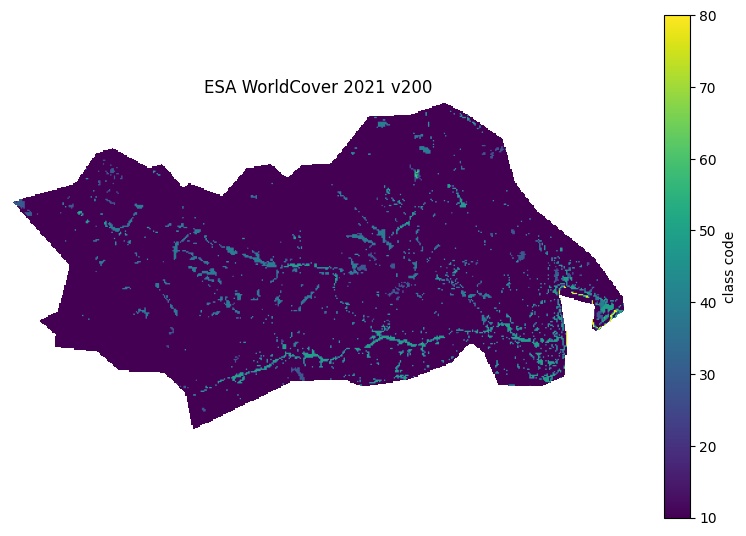

/var/folders/sw/2g04krvs2mvfntsj2sfylnz40000gn/T/ipykernel_14943/2000580018.py:25: RuntimeWarning: invalid value encountered in cast
  n = int(np.sum(study_mask & np.isfinite(landcover) & (landcover.astype("int32")==code)))


,code,cells,area_km2,score
0,10,74603,67.1427,0.25
1,30,649,0.5841,0.55
2,40,1432,1.2888,0.65
3,50,2212,1.9908,0.70
4,60,44,0.0396,0.85
5,80,102,0.0918,0.00


In [8]:

WORLDCOVER_URL = (
    "https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/"
    "ESA_WorldCover_10m_2021_v200_N06E078_Map.tif"
)
lc_raw = download_with_fallback([WORLDCOVER_URL], RAW/"worldcover_2021_N06E078.tif")
lc_float = warp_to_template(lc_raw, transform, width, height, resampling=Resampling.nearest)
landcover = np.where(study_mask, np.rint(lc_float), np.nan).astype("float32")
write_float_tif(PROC/"worldcover_2021_30m_aligned.tif", landcover, transform)

LC_SCORE = {
    10:0.25, 20:0.45, 30:0.55, 40:0.65, 50:0.70, 60:0.85,
    70:0.00, 80:0.00, 90:0.40, 95:0.10, 100:0.20
}
lc_score = np.full(shape, np.nan, dtype="float32")
for code, score in LC_SCORE.items():
    lc_score[np.isfinite(landcover) & (landcover.astype("int32") == code)] = score
lc_score[~study_mask] = np.nan

write_float_tif(PROC/"landcover_score_0_1.tif", lc_score, transform)
plot_raster(landcover, "ESA WorldCover 2021 v200", "class code", FIG/"05_landcover.png", study_mask)

# Class area table.
records = []
for code, score in LC_SCORE.items():
    n = int(np.sum(study_mask & np.isfinite(landcover) & (landcover.astype("int32")==code)))
    if n:
        records.append({"code": code, "cells": n, "area_km2": n*GRID_RES_M**2/1e6, "score": score})
landcover_table = pd.DataFrame(records)
landcover_table.to_csv(TABLE/"landcover_area_by_class.csv", index=False)
display(landcover_table)



## 7. SoilGrids 2.0 – clay at 15–30 cm

SoilGrids is natively **250 m**. This notebook streams the official VRT and aligns it to the reference grid.

SoilGrids raw clay values are stored as **g/kg × 10**, so the notebook divides by 10.

For this first practical index, clay is treated as a regional moisture/material proxy and robust-scaled to 0–1. This simple monotonic relationship must be discussed as a limitation; a future model should calibrate a non-linear soil response against a better local inventory/geotechnical dataset.


Trying official SoilGrids WebDAV/VRT stream...


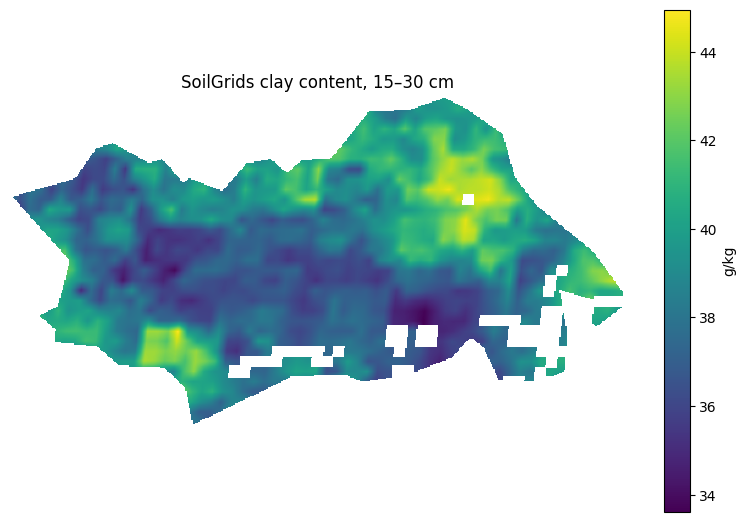

Soil robust scaling: {'p_low': 35.63461151123047, 'p_high': 42.680467987060545, 'invert': False}


In [9]:

SOIL_CLAY_VRT = "https://files.isric.org/soilgrids/latest/data/clay/clay_15-30cm_mean.vrt"
SOIL_WCS = "https://maps.isric.org/mapserv?map=/map/clay.map"

def soilgrids_wcs_subset(boundary4326, out_path):
    """
    Stable SoilGrids WCS fallback.
    Transform AOI bbox to SoilGrids Interrupted Goode Homolosine and request only the local subset.
    """
    igh = CRS.from_proj4("+proj=igh +lat_0=0 +lon_0=0 +datum=WGS84 +units=m +no_defs")
    tr = Transformer.from_crs("EPSG:4326", igh, always_xy=True)
    minlon, minlat, maxlon, maxlat = boundary4326.total_bounds
    # Transform all 4 bbox corners and pad by 1 km.
    corners = [
        tr.transform(minlon, minlat), tr.transform(minlon, maxlat),
        tr.transform(maxlon, minlat), tr.transform(maxlon, maxlat)
    ]
    xs = [x for x,y in corners]
    ys = [y for x,y in corners]
    pad = 1000
    xmin, xmax = min(xs)-pad, max(xs)+pad
    ymin, ymax = min(ys)-pad, max(ys)+pad

    params = [
        ("SERVICE","WCS"),
        ("VERSION","2.0.1"),
        ("REQUEST","GetCoverage"),
        ("COVERAGEID","clay_15-30cm_mean"),
        ("FORMAT","GEOTIFF_INT16"),
        ("SUBSET",f"X({xmin},{xmax})"),
        ("SUBSET",f"Y({ymin},{ymax})"),
        ("SUBSETTINGCRS","http://www.opengis.net/def/crs/EPSG/0/152160"),
        ("OUTPUTCRS","http://www.opengis.net/def/crs/EPSG/0/152160"),
    ]
    print("Trying SoilGrids WCS subset...")
    r = requests.get(SOIL_WCS, params=params, timeout=180)
    r.raise_for_status()
    ctype = r.headers.get("content-type","").lower()
    if "xml" in ctype or len(r.content) < 1000:
        raise RuntimeError("SoilGrids WCS returned an error/very small response: " + r.text[:500])
    Path(out_path).write_bytes(r.content)
    return Path(out_path)

soil_local = RAW/"soilgrids_clay_15_30cm_subset.tif"

try:
    print("Trying official SoilGrids WebDAV/VRT stream...")
    clay_raw = warp_to_template(SOIL_CLAY_VRT, transform, width, height, resampling=Resampling.bilinear)
except Exception as e_vrt:
    print("VRT stream failed:", repr(e_vrt))
    if not soil_local.exists():
        soilgrids_wcs_subset(boundary, soil_local)
    clay_raw = warp_to_template(soil_local, transform, width, height, resampling=Resampling.bilinear)

# SoilGrids clay values are mapped as g/kg x10.
clay_gkg = (clay_raw / 10.0).astype("float32")
clay_gkg = np.where(study_mask, clay_gkg, np.nan)
soil_score, soil_norm = robust_scale(clay_gkg, study_mask, 5, 95)

write_float_tif(PROC/"soilgrids_clay_15_30cm_gkg_30m_aligned.tif", clay_gkg, transform)
write_float_tif(PROC/"soil_score_0_1.tif", soil_score, transform)
plot_raster(clay_gkg, "SoilGrids clay content, 15–30 cm", "g/kg", FIG/"06_soil_clay.png", study_mask)

print("Soil robust scaling:", soil_norm)



## 8. OpenStreetMap roads and streams

The national reproducible archive is the Geofabrik Sri Lanka extract, but downloading the entire country is unnecessary for this small DSD.

The notebook therefore queries OpenStreetMap through **OSMnx/Overpass** using the actual Yatinuwara polygon.

- Road score: exponential distance decay, `exp(-distance/150 m)`
- Stream score: exponential distance decay, `exp(-distance/100 m)`

Distance is measured in metres in UTM 44N.


/var/folders/sw/2g04krvs2mvfntsj2sfylnz40000gn/T/ipykernel_14943/1673013288.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_poly_4326 = boundary.to_crs(4326).geometry.unary_union


Road features: 802
Stream features: 36


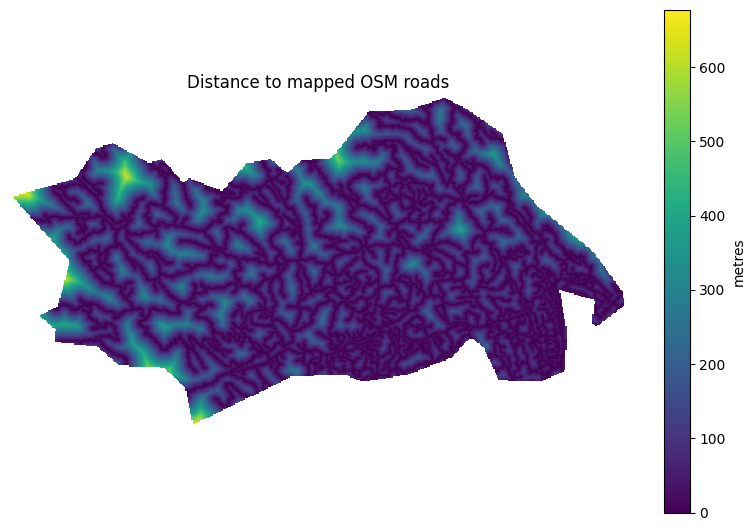

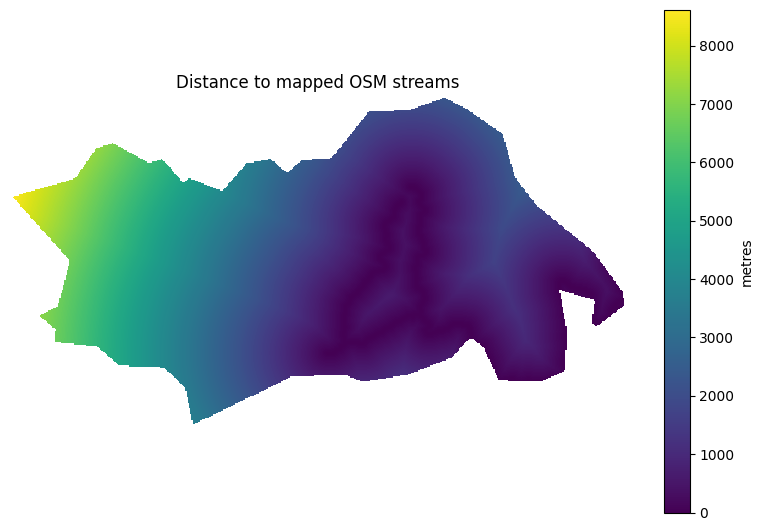

In [10]:

if ox is None:
    raise ImportError("osmnx is required. Install with: pip install osmnx")

study_poly_4326 = boundary.to_crs(4326).geometry.unary_union

def osm_features(tags):
    # OSMnx 2.x
    return ox.features_from_polygon(study_poly_4326, tags)

roads = osm_features({"highway": True}).reset_index()
roads = roads[roads.geometry.notna()].copy()
roads = roads[roads.geometry.geom_type.isin(["LineString","MultiLineString"])].copy()
roads = gpd.GeoDataFrame(roads, geometry="geometry", crs="EPSG:4326").to_crs(TARGET_CRS)

streams = osm_features({"waterway": ["river","stream","canal","drain"]}).reset_index()
streams = streams[streams.geometry.notna()].copy()
streams = streams[streams.geometry.geom_type.isin(["LineString","MultiLineString"])].copy()
streams = gpd.GeoDataFrame(streams, geometry="geometry", crs="EPSG:4326").to_crs(TARGET_CRS)

save_gdf(roads, PROC/"osm_roads_yatinuwara.gpkg", layer="roads")
save_gdf(streams, PROC/"osm_streams_yatinuwara.gpkg", layer="streams")

def distance_to_lines(gdf, shape, transform, mask):
    if len(gdf) == 0:
        out = np.full(shape, np.nan, dtype="float32")
        out[mask] = np.inf
        return out
    burned = rasterize(
        [(g,1) for g in gdf.geometry if g is not None and not g.is_empty],
        out_shape=shape, transform=transform, fill=0, all_touched=True, dtype="uint8"
    )
    dist = distance_transform_edt(burned == 0, sampling=(GRID_RES_M, GRID_RES_M)).astype("float32")
    dist[~mask] = np.nan
    return dist

road_dist = distance_to_lines(roads, shape, transform, study_mask)
stream_dist = distance_to_lines(streams, shape, transform, study_mask)

road_score = np.exp(-road_dist/150.0).astype("float32")
stream_score = np.exp(-stream_dist/100.0).astype("float32")
road_score[~study_mask] = np.nan
stream_score[~study_mask] = np.nan

write_float_tif(PROC/"distance_to_roads_m.tif", road_dist, transform)
write_float_tif(PROC/"distance_to_streams_m.tif", stream_dist, transform)
write_float_tif(PROC/"road_proximity_score_0_1.tif", road_score, transform)
write_float_tif(PROC/"stream_proximity_score_0_1.tif", stream_score, transform)

print("Road features:", len(roads))
print("Stream features:", len(streams))
plot_raster(road_dist, "Distance to mapped OSM roads", "metres", FIG/"07_road_distance.png", study_mask)
plot_raster(stream_dist, "Distance to mapped OSM streams", "metres", FIG/"08_stream_distance.png", study_mask)



## 9. NASA Global Landslide Catalog / COOLR

The service includes fields such as `event_date`, `landslide_category`, `landslide_trigger`, `latitude`, `longitude`, `country_name` and positional-accuracy metadata.

Because Yatinuwara is small and the public global inventory can be sparse, this notebook queries a **25 km buffer** around the DSD. Historical events are given only a **small 0.08 maximum weight** in static susceptibility.

If no usable events are found, the historical-prior factor is removed and the remaining susceptibility weights are automatically renormalized. **Zero catalog events is not interpreted as zero landslide history.**


NASA catalog features in 25 km query envelope: 24
NASA catalog events inside Yatinuwara: 1


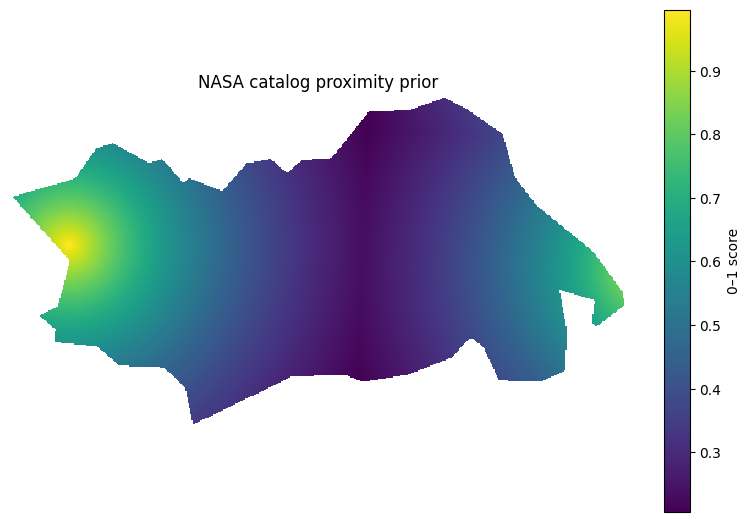

In [11]:

LANDSLIDE_QUERY = (
    "https://services9.arcgis.com/wb84GxCwiPzK3Eow/ArcGIS/rest/services/"
    "nasa_global_landslide_catalog_point/FeatureServer/0/query"
)

buffer_utm = boundary_utm.buffer(25000)
buffer_4326 = gpd.GeoSeries(buffer_utm, crs=TARGET_CRS).to_crs(4326)
bminx, bminy, bmaxx, bmaxy = buffer_4326.total_bounds

params = {
    "where": "1=1",
    "geometry": f"{bminx},{bminy},{bmaxx},{bmaxy}",
    "geometryType": "esriGeometryEnvelope",
    "inSR": "4326",
    "spatialRel": "esriSpatialRelIntersects",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson"
}
r = requests.get(LANDSLIDE_QUERY, params=params, timeout=120)
r.raise_for_status()
ls_js = r.json()
features = ls_js.get("features", [])
print("NASA catalog features in 25 km query envelope:", len(features))

if features:
    landslides = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
    landslides = landslides[landslides.geometry.notna()].copy()
else:
    landslides = gpd.GeoDataFrame({"geometry":[]}, geometry="geometry", crs="EPSG:4326")

# Exact count falling inside Yatinuwara.
if len(landslides):
    inside = gpd.sjoin(landslides, boundary[["geometry"]], how="inner", predicate="within")
    print("NASA catalog events inside Yatinuwara:", len(inside))
else:
    inside = landslides.copy()

if len(landslides):
    save_gdf(landslides, PROC/"nasa_landslides_25km.gpkg", layer="landslides")

# Historical-prior surface: distance from every 30 m cell centre to nearest catalog point.
if len(landslides):
    ls_utm = landslides.to_crs(TARGET_CRS)
    pts = np.array([(g.x, g.y) for g in ls_utm.geometry if g.geom_type=="Point"])
else:
    pts = np.empty((0,2))

if len(pts):
    rows_i, cols_i = np.indices(shape)
    xs = transform.c + (cols_i + 0.5)*transform.a
    ys = transform.f + (rows_i + 0.5)*transform.e
    coords = np.column_stack([xs[study_mask], ys[study_mask]])
    tree = cKDTree(pts)
    d, _ = tree.query(coords, k=1)
    prior = np.full(shape, np.nan, dtype="float32")
    prior[study_mask] = np.exp(-d/5000.0).astype("float32")
    inventory_available = True
else:
    prior = np.full(shape, np.nan, dtype="float32")
    prior[study_mask] = 0.0
    inventory_available = False

write_float_tif(PROC/"landslide_inventory_prior_0_1.tif", prior, transform)
plot_raster(prior, "NASA catalog proximity prior", "0–1 score", FIG/"09_landslide_prior.png", study_mask)



## 10. WorldPop 2024 exposure

WorldPop's 100 m layer is used as a **relative population-exposure surface**.

Because the source stores population at its native grid support, this notebook does not claim that bilinear/average-aligned 30 m values are exact 30 m population counts. The aligned surface is used only to normalize **relative exposure (E)**.

For reporting actual exposed persons, a stricter area-preserving population allocation should be added.


Downloading: https://data.worldpop.org/GIS/Population/Global_2015_2030/R2024A/2024/LKA/v1/100m/unconstrained/lka_pop_2024_UC_100m_R2024A_v1.tif


100%|██████████| 36.3M/36.3M [00:56<00:00, 646kB/s]


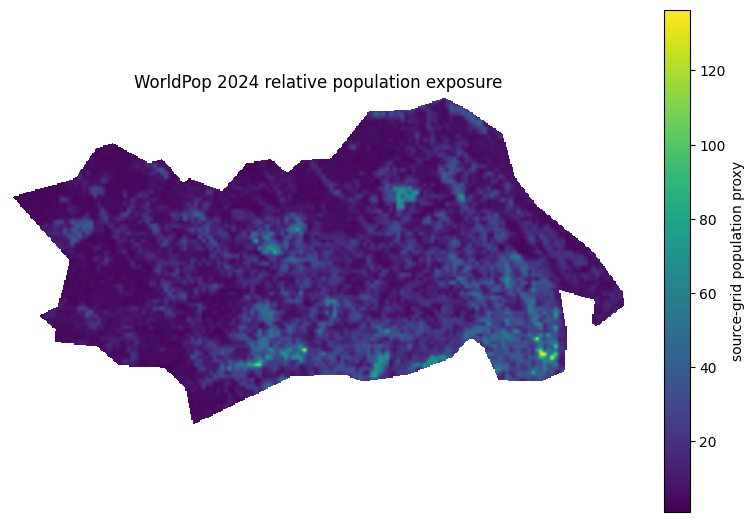

Population exposure robust scaling: {'p_low': 3.734005033969879, 'p_high': 37.56622467041015, 'invert': False}


In [12]:

WORLDPOP_URL = (
    "https://data.worldpop.org/GIS/Population/Global_2015_2030/R2024A/2024/"
    "LKA/v1/100m/unconstrained/lka_pop_2024_UC_100m_R2024A_v1.tif"
)
pop_raw_path = download_with_fallback([WORLDPOP_URL], RAW/"worldpop_lka_2024_100m.tif")
pop_proxy = warp_to_template(pop_raw_path, transform, width, height, resampling=Resampling.bilinear)
pop_proxy = np.where(study_mask, pop_proxy, np.nan).astype("float32")
exposure_score, pop_norm = robust_scale(pop_proxy, study_mask, 5, 95)

write_float_tif(PROC/"worldpop_2024_relative_exposure_aligned.tif", pop_proxy, transform)
write_float_tif(PROC/"exposure_score_0_1.tif", exposure_score, transform)
plot_raster(pop_proxy, "WorldPop 2024 relative population exposure", "source-grid population proxy", FIG/"10_population.png", study_mask)

print("Population exposure robust scaling:", pop_norm)



## 11. Normalize susceptibility indicators and compute S, T and E

### Static susceptibility, \(S\)

Baseline weights:

- Slope: **0.40**
- Land cover: **0.15**
- Soil (clay proxy): **0.12**
- Road proximity: **0.15**
- Stream proximity: **0.10**
- Historical landslide prior: **0.08**

If the NASA inventory query contains no usable nearby events, the 0.08 inventory weight is dropped and the remaining factors are renormalized.

Slope uses robust 5th–95th percentile scaling inside Yatinuwara.

### Trigger, \(T\)
For this baseline run, \(T\) is the normalized CHIRPS climatological rainfall potential.

### Exposure, \(E\)
\(E\) is the robust-normalized WorldPop relative population exposure.


Static susceptibility weights: {'slope': 0.4, 'landcover': 0.15, 'soil': 0.12, 'road': 0.15, 'stream': 0.1, 'landslide_prior': 0.08}
Weight sum: 1.0


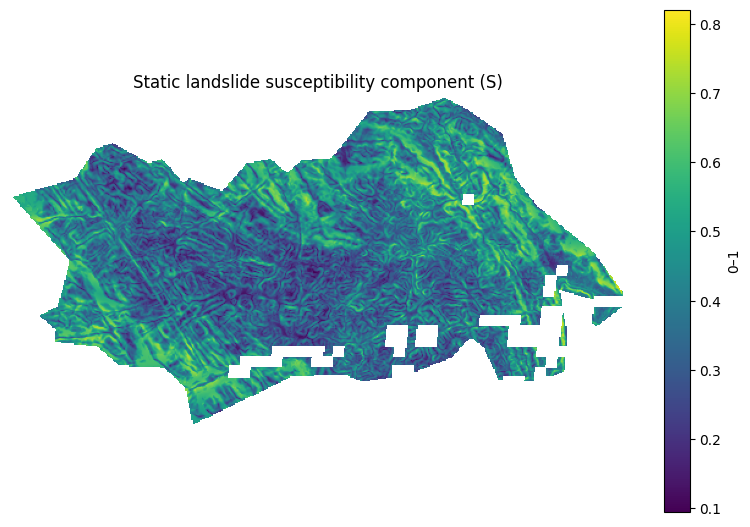

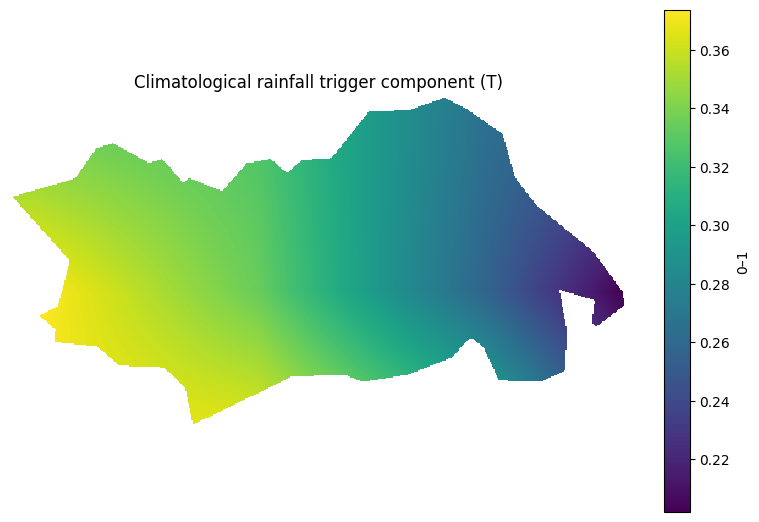

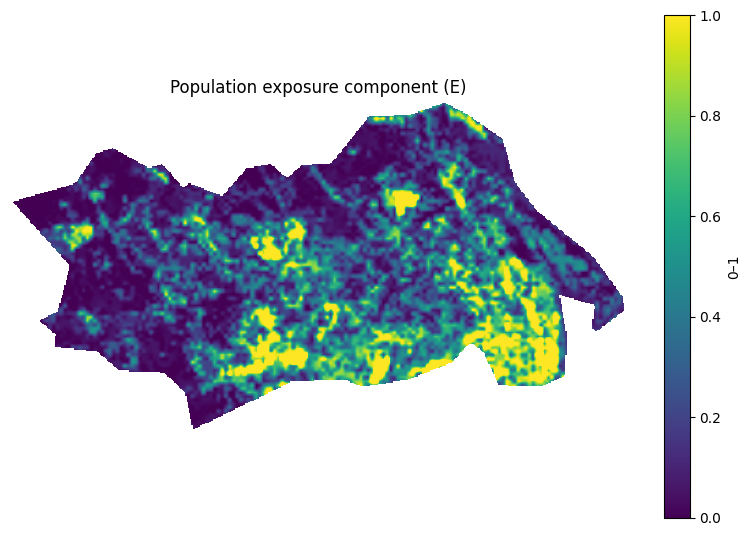

In [13]:

slope_score, slope_norm = robust_scale(slope, study_mask, 5, 95)

layers_S = {
    "slope": slope_score,
    "landcover": lc_score,
    "soil": soil_score,
    "road": road_score,
    "stream": stream_score,
    "landslide_prior": prior
}
weights_S = {
    "slope": 0.40,
    "landcover": 0.15,
    "soil": 0.12,
    "road": 0.15,
    "stream": 0.10,
    "landslide_prior": 0.08
}

if not inventory_available:
    print("No usable nearby NASA inventory points: dropping landslide_prior weight.")
    weights_S.pop("landslide_prior")
    layers_S.pop("landslide_prior")

# Renormalize.
w_sum = sum(weights_S.values())
weights_S = {k:v/w_sum for k,v in weights_S.items()}
print("Static susceptibility weights:", weights_S)
print("Weight sum:", sum(weights_S.values()))

S = np.zeros(shape, dtype="float32")
validS = study_mask.copy()
for k, arr in layers_S.items():
    validS &= np.isfinite(arr)

S[:] = np.nan
S[validS] = 0.0
for k, w in weights_S.items():
    S[validS] += w * layers_S[k][validS]

T = rain_score.copy()
E = exposure_score.copy()

write_float_tif(PROC/"S_static_susceptibility_0_1.tif", S, transform)
write_float_tif(PROC/"T_rainfall_trigger_0_1.tif", T, transform)
write_float_tif(PROC/"E_exposure_0_1.tif", E, transform)

plot_raster(S, "Static landslide susceptibility component (S)", "0–1", FIG/"11_static_susceptibility_S.png", study_mask)
plot_raster(T, "Climatological rainfall trigger component (T)", "0–1", FIG/"12_trigger_T.png", study_mask)
plot_raster(E, "Population exposure component (E)", "0–1", FIG/"13_exposure_E.png", study_mask)



## 12. Final 0–100 LS-LRSI

The final interpretable index follows the report design:

\[
\mathrm{LS\!-\!LRSI}
=
100 \times
\frac{
0.55S + 0.25T + 0.20E + 0.15ST + 0.10SE
}{1.25}
\]

The interaction terms increase risk where:
- susceptible terrain coincides with stronger rainfall pressure (\(S \times T\)), and
- susceptible terrain coincides with higher exposure (\(S \times E\)).

### Classes
- **Low:** 0–20
- **Moderate:** >20–40
- **High:** >40–60
- **Very High:** >60–100


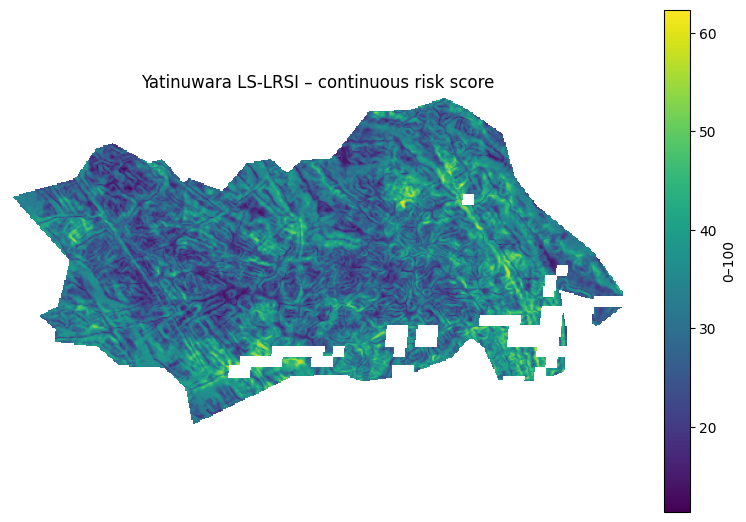

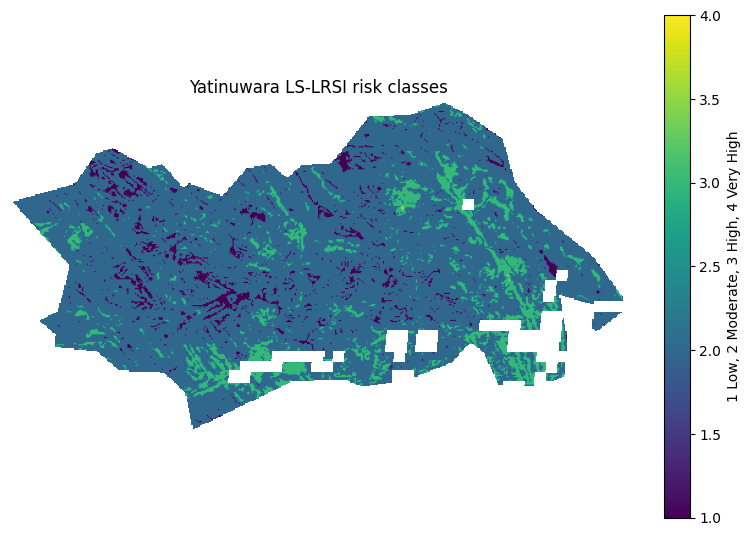

,class_code,risk_class,cells,area_km2,percent_valid_area
0,1,Low,4210,3.7890,5.601011
1,2,Moderate,62578,56.3202,83.254174
2,3,High,8372,7.5348,11.138163
3,4,Very High,5,0.0045,0.006652


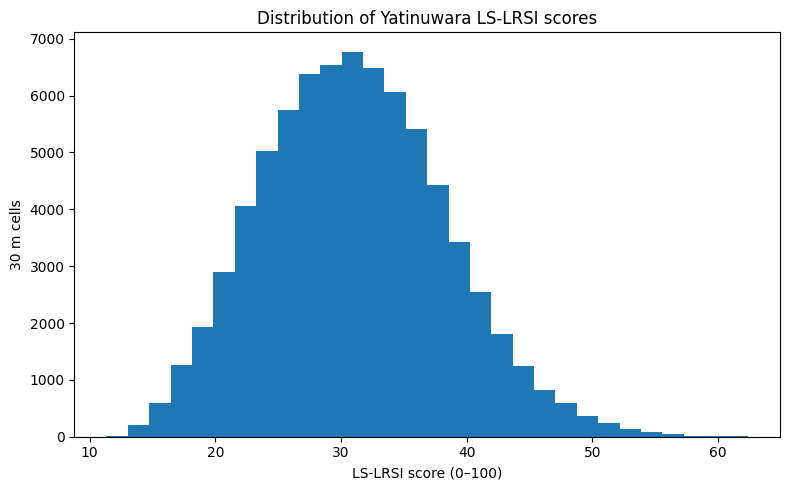

In [14]:

valid = study_mask & np.isfinite(S) & np.isfinite(T) & np.isfinite(E)

risk = np.full(shape, np.nan, dtype="float32")
risk[valid] = 100.0 * (
    0.55*S[valid] +
    0.25*T[valid] +
    0.20*E[valid] +
    0.15*S[valid]*T[valid] +
    0.10*S[valid]*E[valid]
) / 1.25
risk = np.clip(risk, 0, 100)

classes = np.zeros(shape, dtype="uint8")  # 0 outside/no data
classes[valid & (risk <= 20)] = 1
classes[valid & (risk > 20) & (risk <= 40)] = 2
classes[valid & (risk > 40) & (risk <= 60)] = 3
classes[valid & (risk > 60)] = 4

write_float_tif(OUT/"Yatinuwara_LS_LRSI_0_100.tif", risk, transform)
write_byte_tif(OUT/"Yatinuwara_LS_LRSI_classes.tif", classes, transform)

plot_raster(risk, "Yatinuwara LS-LRSI – continuous risk score", "0–100", FIG/"14_final_lslrsi_0_100.png", study_mask)

# Separate class figure; use default colormap.
class_plot = classes.astype("float32")
class_plot[~valid] = np.nan
plot_raster(class_plot, "Yatinuwara LS-LRSI risk classes", "1 Low, 2 Moderate, 3 High, 4 Very High",
            FIG/"15_final_risk_classes.png", study_mask)

# Risk-area summary.
labels = {1:"Low", 2:"Moderate", 3:"High", 4:"Very High"}
summary = []
nvalid = int(valid.sum())
for c, label in labels.items():
    n = int(np.sum(classes==c))
    summary.append({
        "class_code": c,
        "risk_class": label,
        "cells": n,
        "area_km2": n*GRID_RES_M**2/1e6,
        "percent_valid_area": (100*n/nvalid) if nvalid else np.nan
    })
risk_summary = pd.DataFrame(summary)
risk_summary.to_csv(TABLE/"risk_class_area_summary.csv", index=False)
display(risk_summary)

# Score distribution.
rv = risk[valid]
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(rv, bins=30)
ax.set_xlabel("LS-LRSI score (0–100)")
ax.set_ylabel("30 m cells")
ax.set_title("Distribution of Yatinuwara LS-LRSI scores")
fig.tight_layout()
fig.savefig(FIG/"16_lslrsi_histogram.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)



## 13. EDA summary statistics

This table supplies reproducible values for the report.  
Copy the generated results into the EDA/results sections only after a successful full notebook run.


In [15]:

stats = pd.DataFrame([
    raster_stats("Elevation (m)", dem, study_mask),
    raster_stats("Slope (degrees)", slope, study_mask),
    raster_stats("CHIRPS climatology (mm/year)", rain, study_mask),
    raster_stats("Soil clay 15–30 cm (g/kg)", clay_gkg, study_mask),
    raster_stats("Distance to roads (m)", road_dist, study_mask),
    raster_stats("Distance to streams (m)", stream_dist, study_mask),
    raster_stats("Population exposure proxy", pop_proxy, study_mask),
    raster_stats("Static susceptibility S", S, study_mask),
    raster_stats("Trigger T", T, study_mask),
    raster_stats("Exposure E", E, study_mask),
    raster_stats("Final LS-LRSI", risk, study_mask),
])
stats.to_csv(TABLE/"eda_summary_statistics.csv", index=False)
display(stats)


,feature,n,min,p05,median,mean,p95,max,std
0,Elevation (m),79042,298.155121,4.860449e+02,547.619141,562.725403,680.168091,987.668152,60.928890
1,Slope (degrees),79042,0.000000,2.939443e+00,13.185575,14.048781,27.833847,67.028412,7.762904
2,CHIRPS climatology (mm/year),79042,1903.673950,1.982213e+03,2130.679199,2119.552734,2223.966797,2247.734863,79.757126
3,Soil clay 15–30 cm (g/kg),75165,33.606792,3.563461e+01,38.240150,38.601177,42.680470,44.954124,2.177843
4,Distance to roads (m),79042,0.000000,0.000000e+00,60.000000,89.596725,276.586334,676.830872,92.345375
5,Distance to streams (m),79042,0.000000,9.000000e+01,1643.441528,2353.223145,6590.857422,8614.232422,2120.708740
6,Population exposure proxy,79042,0.787743,3.734005e+00,11.322088,14.961381,37.566216,136.454865,11.882990
7,Static susceptibility S,75165,0.094904,2.141434e-01,0.392274,0.402758,0.617927,0.820489,0.124020
8,Trigger T,79042,0.201837,2.411062e-01,0.315340,0.309776,0.361983,0.373867,0.039879
9,Exposure E,79042,0.000000,1.558045e-07,0.224286,0.314725,0.999997,1.000000,0.291273



## 14. Correlation diagnostic

Correlation is an exploratory diagnostic, not a weight generator by itself.  
Only continuous aligned features are included.


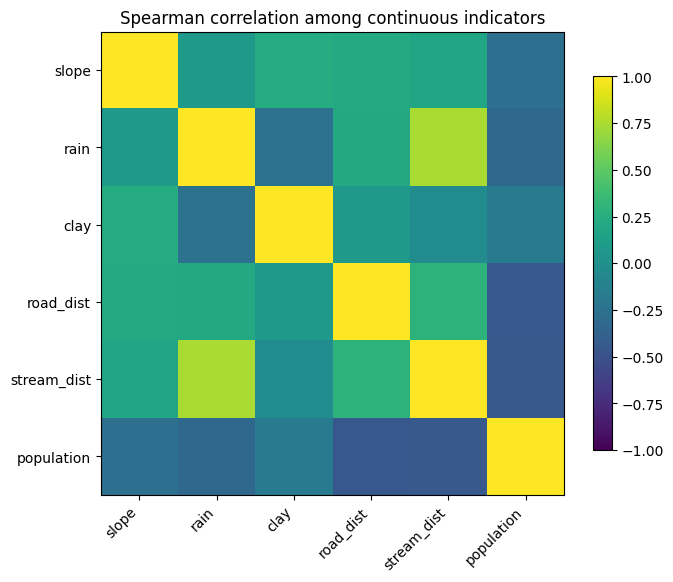

In [16]:

feature_dict = {
    "slope": slope,
    "rain": rain,
    "clay": clay_gkg,
    "road_dist": road_dist,
    "stream_dist": stream_dist,
    "population": pop_proxy,
}
df = pd.DataFrame({k:v[study_mask] for k,v in feature_dict.items()})
df = df.replace([np.inf,-np.inf], np.nan).dropna()
corr = df.corr(method="spearman")
corr.to_csv(TABLE/"spearman_correlation.csv")

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
ax.set_title("Spearman correlation among continuous indicators")
fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
fig.savefig(FIG/"17_spearman_correlation.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)



## 15. Weight sensitivity

A simple reproducible sensitivity test perturbs each static susceptibility weight by ±20%, renormalizes all weights, recomputes the final risk surface, and measures how many cells change risk class.

For a stronger dissertation-style analysis, replace this with Monte Carlo/Dirichlet weight simulation.


In [17]:

def compute_S(weight_dict):
    w = {k:v/sum(weight_dict.values()) for k,v in weight_dict.items()}
    out = np.full(shape, np.nan, dtype="float32")
    ok = study_mask.copy()
    for k in w:
        ok &= np.isfinite(layers_S[k])
    out[ok] = 0
    for k,v in w.items():
        out[ok] += v*layers_S[k][ok]
    return out

def compute_risk(Sx):
    ok = study_mask & np.isfinite(Sx) & np.isfinite(T) & np.isfinite(E)
    rr = np.full(shape, np.nan, dtype="float32")
    rr[ok] = 100 * (
        0.55*Sx[ok] + 0.25*T[ok] + 0.20*E[ok] +
        0.15*Sx[ok]*T[ok] + 0.10*Sx[ok]*E[ok]
    ) / 1.25
    return np.clip(rr,0,100)

def classify(rr):
    cc = np.zeros(shape, dtype="uint8")
    ok = study_mask & np.isfinite(rr)
    cc[ok & (rr<=20)] = 1
    cc[ok & (rr>20) & (rr<=40)] = 2
    cc[ok & (rr>40) & (rr<=60)] = 3
    cc[ok & (rr>60)] = 4
    return cc

sens = []
base = classes.copy()
for factor_name in list(weights_S):
    for mult in [0.8, 1.2]:
        w = weights_S.copy()
        w[factor_name] *= mult
        Sx = compute_S(w)
        rx = compute_risk(Sx)
        cx = classify(rx)
        denom = np.sum(valid)
        changed = np.sum((cx != base) & valid)
        sens.append({
            "factor": factor_name,
            "multiplier": mult,
            "percent_cells_changing_class": 100*changed/denom if denom else np.nan
        })

sens_df = pd.DataFrame(sens)
sens_df.to_csv(TABLE/"weight_sensitivity.csv", index=False)
display(sens_df)


,factor,multiplier,percent_cells_changing_class
0,slope,0.8,2.675447
1,slope,1.2,2.797845
2,landcover,0.8,1.156123
3,landcover,1.2,1.051021
4,soil,0.8,1.110889
5,soil,1.2,0.955232
6,road,0.8,1.992949
7,road,1.2,1.850595
8,stream,0.8,1.672321
9,stream,1.2,1.557906



## 16. Export run metadata

The metadata file records the exact index design used to create the final raster.


In [18]:

metadata = {
    "study_area": "Yatinuwara Divisional Secretariat Division, Kandy District, Sri Lanka",
    "boundary_source": boundary_source,
    "target_crs": TARGET_CRS,
    "grid_resolution_m": GRID_RES_M,
    "static_weights": weights_S,
    "slope_normalization": slope_norm,
    "soil_normalization": soil_norm,
    "population_exposure_normalization": pop_norm,
    "rainfall_normalization": {
        "method": "fixed linear scaling",
        "low_mm_year": 1500,
        "high_mm_year": 3500,
        "warning": "These are index scaling anchors, not NBRO warning thresholds."
    },
    "road_decay_m": 150,
    "stream_decay_m": 100,
    "landslide_prior_decay_m": 5000,
    "final_formula": "100*(0.55*S + 0.25*T + 0.20*E + 0.15*S*T + 0.10*S*E)/1.25",
    "risk_classes": {
        "Low": "0-20",
        "Moderate": ">20-40",
        "High": ">40-60",
        "Very High": ">60-100"
    }
}
with open(OUT/"run_metadata.json","w",encoding="utf-8") as f:
    json.dump(metadata,f,indent=2)

print("Core outputs:")
for pth in [
    OUT/"Yatinuwara_LS_LRSI_0_100.tif",
    OUT/"Yatinuwara_LS_LRSI_classes.tif",
    TABLE/"risk_class_area_summary.csv",
    TABLE/"eda_summary_statistics.csv",
    OUT/"run_metadata.json"
]:
    print(" -", pth)


Core outputs:
 - /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/outputs/Yatinuwara_LS_LRSI_0_100.tif
 - /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/outputs/Yatinuwara_LS_LRSI_classes.tif
 - /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/outputs/tables/risk_class_area_summary.csv
 - /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/outputs/tables/eda_summary_statistics.csv
 - /Users/damithkayatech.com/Documents/MSc/Geo_Analysis_Assignment/Yatinuwara_LS_LRSI_Practical/outputs/run_metadata.json



## 17. How to update the index later

### A. New rainfall
Keep the static terrain/land-cover/soil/road/stream layers unchanged and replace \(T\) with a recent rainfall trigger.

A future event formulation can use:

\[
T_{\mathrm{event}}=0.45R_1+0.35R_3+0.20R_7
\]

where \(R_1,R_3,R_7\) are normalized 1-day, 3-day and 7-day accumulated rainfall.

### B. New land cover or roads
Re-download ESA WorldCover / updated Sentinel-2 classification and OpenStreetMap, then rebuild only those scores and \(S\).

### C. Better local inventory
Replace or supplement NASA COOLR with dated NBRO/DMC/local landslide locations. Keep some events completely out of calibration for validation.

### D. Better population
Replace the relative WorldPop exposure proxy with a count-preserving gridded population allocation or GN-level census-based exposure analysis.

### E. Validation
The most important next improvement is to compare the static component \(S\) with:
1. independent historical landslides, and
2. NBRO landslide hazard zonation for Yatinuwara.

Do **not** use the NBRO hazard class directly as a predictor and then validate against the same class.
